In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.interpolate import make_interp_spline
from pyquaternion import Quaternion
from typing import Optional
from jaxtyping import Float, jaxtyped
from numpy.typing import NDArray
from beartype import beartype
import matplotlib.pyplot as plt
from functools import lru_cache
np.set_printoptions(precision=3, suppress=True, linewidth=200)

#@jaxtyped(typechecker=beartype)
def create_skew_matrix(
    input_vector: Float[NDArray, "3"]|Float[NDArray, "3 1"]|Float[NDArray, "1 3"],
) -> Float[NDArray, "3 3"]:
    
    input_vector = input_vector.reshape(3,)
    output_matrix = np.zeros((3, 3))
    output_matrix[1, 2], output_matrix[2, 1] = -input_vector[0], input_vector[0]
    output_matrix[2, 0], output_matrix[0, 2] = -input_vector[1], input_vector[1]
    output_matrix[1, 0], output_matrix[0, 1] = input_vector[2], -input_vector[2]

    return output_matrix

def spatial_cross_product(spatial_vel, transpose_and_negate = False): #TODO typehinting
    spatial_vel = np.asarray(spatial_vel).reshape(6,)
    angular_vel, linear_vel = np.split(spatial_vel, 2)
    spatial_cross_vel = np.block([
        [create_skew_matrix(angular_vel), np.zeros((3,3))],
        [create_skew_matrix(linear_vel), create_skew_matrix(angular_vel)]
        ])
    if transpose_and_negate:
        spatial_cross_vel = -spatial_cross_vel.T

    return spatial_cross_vel

def get_linear_velocity(generalized_velocity, quaternion): #TODO typehinting
    linear_velocity = get_rotation_matrix(quaternion) @ generalized_velocity

    return linear_velocity

def get_quaternion_rate(quaternion, angular_velocity): #TODO typehinting
    """
    Input: quaternion vector first scalar last and angular velocity
    Output: quaternion rate

    This function takes unit quaternions and angular velocity to get the quaternion rate.
    """
    angular_velocity = angular_velocity.reshape(3,)
    ang_vel_tilde = create_skew_matrix(angular_velocity)
    quaternion_rate = 0.5 * np.block([
        [-ang_vel_tilde, angular_velocity.reshape(3,1)],
        [-angular_velocity, 0]
        ]) @ quaternion
    
    return quaternion_rate

def get_revolute_quaternion(angle, joint_axis):
    """
    Input: angle and joint axis of rotation
    Output: unit quaternion describing the attitude.
    
    This function is based on eq. B.12
    """
    
    if joint_axis == "x":
        n = np.array([1, 0, 0])
    elif joint_axis == "y":
        n = np.array([0, 1, 0])
    elif joint_axis == "z":
        n = np.array([0, 0, 1])
    else:
        print("unsupported")
        pass
        
    quaternion_vector = np.sin(angle/2)*n
    quaternion_scalar = np.array([np.cos(angle/2)])

    quaternion = np.concatenate((quaternion_vector, quaternion_scalar))

    return quaternion

def get_rotation_matrix(quarternion_scalar_last): #TODO typehinting
    """
    Input: quaternion with scalar part last
    Output: orthogonal rotation matrix 3x3
    """
    rotation_matrix = Quaternion(scalar=quarternion_scalar_last[-1], vector=quarternion_scalar_last[0:3]).rotation_matrix

    return rotation_matrix
    
def Equations_of_motion(spatial_inertia, forces, spatial_vel):
    """
    Input: spatial_inertia of a body, forces acting on the body and spatial velocity
    Output: generalized acceleration of the body

    Note that this is the implementation of lemma 2.3    
    """
    spatial_vel = spatial_vel.reshape(6,1)
    beta_b_dot = np.linalg.inv(spatial_inertia) @ (forces - spatial_cross_product(spatial_vel, True) @ spatial_inertia @ spatial_vel)
    
    return beta_b_dot.reshape(6,)

def get_gamma(time):
    """
    Input: Time as a float
    Output: List of np.arrays with acceleration values for each joint
    """
    def _acc_function(time):
        acceleration_value = np.sin(2*time*np.pi*1e-3)
    
        return acceleration_value

    A = _acc_function(time)
    #if necessary .reshape(3,1)
    gamma = [
             np.array([-2*A, 0, -2*A])*1e-6,
             np.array([-8*A])*1e-6,
             np.array([4*A])*1e-6,
             np.array([5*A, 0, 6*A])*1e-6
             ]
    
    return gamma
    
def state_space_differentiation(time, state, hinge_list, hinge_distances, spatial_inertias, force_function): #TODO typehinting
    """
    Input: State 18x1 in assignment 2, spatial_inertia and forces
    Output: State derivative 18x1 in assignment 2
    """
    def _diff_theta(theta, beta, accelerations, hinge_list):
        """
        Handles spherical hinges and revolute hinges as suggested in the assignment
        """
        theta_dot = np.empty_like(theta)
        beta_dot = np.empty_like(beta)
        theta_count = 0
        beta_count = 0

        for index, hinge in enumerate(hinge_list):
            if hinge == "f":
                theta_normalized = theta[theta_count:theta_count+4] / np.linalg.norm(theta[theta_count:theta_count+4])
                theta_position = theta[theta_count+4:theta_count+7]
                theta_rotation = get_rotation_matrix(theta_normalized)
                
                theta_dot[theta_count:theta_count+4] = get_quaternion_rate(theta_normalized, beta[beta_count:beta_count+3])
                theta_dot[theta_count+4:theta_count+7] = beta[beta_count+3:beta_count+6] - np.cross(beta[beta_count:beta_count+3], theta_position)
                #theta_rotation @ beta[beta_count+3:beta_count+6]
                #beta[beta_count+3:beta_count+6] - np.cross(beta[beta_count:beta_count+3], theta_position)#get_linear_velocity(beta[beta_count+3:beta_count+6], theta_normalized).reshape(3,)


                beta_dot[beta_count:beta_count+3] = accelerations[beta_count:beta_count+3]
                beta_dot[beta_count+3:beta_count+6] = accelerations[beta_count+3:beta_count+6]


                theta_count += 7
                beta_count += 6
            elif hinge == "s":
                theta_normalized = theta[theta_count:theta_count+4] / np.linalg.norm(theta[theta_count:theta_count+4])
                theta_dot[theta_count:theta_count+4] = get_quaternion_rate(theta_normalized, beta[beta_count:beta_count+3])
                beta_dot[beta_count:beta_count+3] = accelerations[beta_count:beta_count+3]
                
                theta_count += 4
                beta_count += 3
            elif hinge in {"x", "y", "z"}:
                theta_dot[theta_count] = beta[beta_count]
                beta_dot[beta_count] = accelerations[beta_count]

                theta_count += 1
                beta_count += 1
            else:
                print(f"Unsupported hingetype: {hinge}")
                pass

        return theta_dot, beta_dot

    theta = state[0:17].copy()
    beta = state[17:31].copy()

    generalized_forces = force_function(time)

    spatial_velocities, a_tensor, phi_transposed_tensor, _ = scatter_function(theta, beta, hinge_distances, hinge_list)
    beta_dot_tensor, spatial_alpha = ATBI_function(spatial_velocities, spatial_inertias, a_tensor, phi_transposed_tensor, generalized_forces, hinge_list)

    theta_dot, beta_dot = _diff_theta(theta, beta, beta_dot_tensor, hinge_list)
    state_diff = np.concatenate((theta_dot, beta_dot))

    return state_diff

def scatter_function(theta, beta, hinge_distances, hinge_list, base_state=np.zeros((12))):
    """
    Input: orientations, velocities, accelerations and hinge distances / list
    Output: spatial orientations, rotations, velocities and accelerations
    """
    
    parent_velocity = np.asarray(base_state).reshape(-1)[:6]
    #a_tensor = base_state[6:].reshape(6,)
    theta_count=len(theta)
    beta_count=len(beta)


    spatial_orientations = np.zeros((len(hinge_list)*4))
    spatial_rotations = np.zeros((len(hinge_list), 3, 3))
    spatial_velocities = np.concatenate((parent_velocity, np.zeros((len(hinge_list)*6))))
    delta_v_tensor = np.zeros_like(spatial_velocities)
    a_tensor = np.zeros_like(spatial_velocities)
    phi_transposed_tensor = np.zeros((len(hinge_list), 6, 6))
    #phi_position = np.zeros(3)

    #scatterloop
    for index, hinge in zip(range(len(hinge_list)-1, -1, -1), reversed(hinge_list)):
        hinge_map_transposed = get_hinge_map_transposed(hinge)
        
        if hinge == "s":
            theta_quaternion = theta[theta_count-4:theta_count] / np.linalg.norm(theta[theta_count-4:theta_count])
            rotation_matrix = get_rotation_matrix(theta_quaternion)
            spatial_orientations[index*4:(index+1)*4] = theta_quaternion
            spatial_rotations[index, :, :] = rotation_matrix

            delta_v = hinge_map_transposed @ beta[beta_count-3:beta_count]

            theta_count -= 4
            beta_count -= 3

        elif hinge in {"x", "y", "z"}:
            theta_quaternion = get_revolute_quaternion(theta[theta_count-1], hinge)
            theta_quaternion = theta_quaternion / np.linalg.norm(theta_quaternion)
            rotation_matrix = get_rotation_matrix(theta_quaternion)
            spatial_orientations[index*4:(index+1)*4] = theta_quaternion
            spatial_rotations[index, :, :] = rotation_matrix

            delta_v = hinge_map_transposed[:, 0] * beta[beta_count-1]

            theta_count -= 1
            beta_count -= 1
        
        elif hinge == "f":

            theta_position = theta[theta_count-3:theta_count]

            theta_count -= 3
            
            theta_quaternion = theta[theta_count-4:theta_count] / np.linalg.norm(theta[theta_count-4:theta_count])
            theta_count -= 4
            
            rotation_matrix = get_rotation_matrix(theta_quaternion)
            spatial_rotations[index, :, :] = rotation_matrix
            spatial_orientations[index*4:(index+1)*4] = theta_quaternion

            delta_v = beta[beta_count-6:beta_count] #hinge_map_transposed @ beta[beta_count-6:beta_count] #identity mapping.

            beta_count -= 6

        else:
            print(f"Unsupported hingetype: {hinge}")
            pass

        #calculate velocity
        if hinge == "f":
            r_parent = hinge_distances[index, :] - theta_position# + rotation_matrix @ theta_position
            phi_transposed = create_phi(r_parent, rotation_matrix, True)
            #phi_transposed = create_phi(hinge_distances[index, :]+theta_position, rotation_matrix, True)
        else:
            phi_transposed = create_phi(hinge_distances[index, :], rotation_matrix, True)
        
        phi_transposed_tensor[index, :, :] = phi_transposed
        parent_velocity = phi_transposed @ parent_velocity + delta_v
        delta_v_tensor[(index+1)*6:(index+2)*6] = delta_v

        #Changed to general form
        coriolis_term = spatial_cross_product(parent_velocity) @ delta_v

        if hinge == "f":
            coriolis_term = coriolis_term - spatial_cross_product(delta_v, True) @ delta_v 


        spatial_velocities[(index+1)*6:(index+2)*6] = parent_velocity
        a_tensor[(index+1)*6:(index+2)*6] = coriolis_term


    return spatial_velocities, a_tensor, phi_transposed_tensor, spatial_rotations #delta_v_tensor spatial_orientations, spatial_rotations, 

def ATBI_function(spatial_velocities, spatial_inertias, a_tensor, phi_transposed_tensor, generalized_forces, hinge_list):
    """
    Input: spatial velocities, spatial inertias, acceleration bias, generalized forces and hinge list
    Output: spatial forces for and accelerations
    """
    def get_hinge_dof(hinge_type: str)-> int: 
        if hinge_type == "f":
            dof = 6
        elif hinge_type == "s":
            dof = 3
        elif hinge_type in {"x", "y", "z"}:
            dof = 1
        else:
            raise ValueError
        return dof

    generalized_forces = generalized_forces.reshape(-1)
    P = np.zeros((6,6))
    #G = np.zeros_like(child_eff_inertia)
    P_plus = np.zeros_like(P)
    z_plus = np.zeros(6)
    alpha = np.zeros(6)
    beta_dot = np.zeros_like(z_plus)
    
    spatial_alpha = np.zeros_like(spatial_velocities)
    G_tensor = np.zeros((generalized_forces.shape[0], 6))
    Nu_tensor = np.zeros_like(generalized_forces)
    beta_dot_tensor = np.zeros_like(generalized_forces)

    force_count = 0

    #gatherloop atbi
    for index, hinge in enumerate(hinge_list):
        
        hinge_dof = get_hinge_dof(hinge)
        hinge_map = get_hinge_map_transposed(hinge, False)
        hinge_map_transposed = hinge_map.T

        phi_transposed = phi_transposed_tensor[index, :, :]
        phi = phi_transposed.T
        P = spatial_inertias[index, :, :] + P_plus
        #P = phi @ P_plus @ phi_transposed + spatial_inertias[index, :, :]

        M = spatial_inertias[index, :, :]
        V = spatial_velocities[(index+1)*6:(index+2)*6]
        b = spatial_cross_product(V, transpose_and_negate=True) @ (M @ V)
        a = a_tensor[(index+1)*6:(index+2)*6]

        z = z_plus + P @ a + b
        #z = phi @ z_plus + P @ a + b

        D = hinge_map @ P @ hinge_map_transposed
        D_inv = np.linalg.inv(D)

        G = P @ hinge_map_transposed @ D_inv
        Tau = np.eye(6) - G @ hinge_map
        P_plus_local = Tau @ P
        #P_plus = Tau @ P

        T = generalized_forces[force_count:force_count+hinge_dof]
        eps = T - (hinge_map @ z)
        Nu = D_inv @ eps
        z_plus_local = z + G @ eps
        #z_plus = z + G @ eps

        if index < len(hinge_list) - 1:
            # X = phi_transposed maps parent->child motion
            # X* = phi maps child->parent forces
            P_plus = phi @ P_plus_local @ phi_transposed
            z_plus = phi @ z_plus_local
        else:
            # last body: keep local (not used further anyway)
            P_plus = P_plus_local
            z_plus = z_plus_local

        G_tensor[force_count:force_count+hinge_dof] = G.T
        Nu_tensor[force_count:force_count+hinge_dof] = Nu
        force_count += hinge_dof


    for index, hinge in zip(range(len(hinge_list)-1, -1, -1), reversed(hinge_list)):
        
        hinge_dof = get_hinge_dof(hinge)
        hinge_map_transposed = get_hinge_map_transposed(hinge)
        force_count -= hinge_dof
        if index == len(hinge_list)-1:
            alpha_plus = np.zeros(6)
        else:
            alpha_plus = phi_transposed_tensor[index] @ alpha

        G_Transposed = G_tensor[force_count:force_count+hinge_dof, :]
        Nu = Nu_tensor[force_count:force_count+hinge_dof]

        beta_dot = Nu - (G_Transposed @ alpha_plus)
        a = a_tensor[(index+1)*6:(index+2)*6]
        alpha = alpha_plus + hinge_map_transposed @ beta_dot + a

        spatial_alpha[(index+1)*6:(index+2)*6] = alpha
        beta_dot_tensor[force_count:force_count+hinge_dof] = beta_dot

    return beta_dot_tensor, spatial_alpha
    
#@jaxtyped(typechecker=beartype)
def create_phi(position: Optional[Float[NDArray, "3 1"]|Float[NDArray, "3"]|Float[NDArray, "1 3"]]=None, 
               rotation: Optional[Float[NDArray, "3 3"]]=None, transpose=False) -> Float[NDArray, "6 6"]:
    
    def _create_phi_rotation(rotation_matrix: Float[NDArray, "3 3"]) -> Float[NDArray, "6 6"]:
        phi_rotation = np.kron(np.eye(2), rotation_matrix)
        return phi_rotation

    phi = np.eye(6)
    if position is not None:
        phi[0:3,3:6] = create_skew_matrix(position)
    if rotation is not None:
        phi = phi @ _create_phi_rotation(rotation)
    if transpose:
        phi = phi.T

    return phi

@lru_cache(None)
def get_hinge_map_transposed(hingetype="s", transposed=True):
    """
    Input: Hingetype and transpose option
    Output: Hingemap transposed unless option chosen
    """
    if hingetype == "f":
        hingemap = np.eye(6)
    elif hingetype == "s":
        hingemap = np.concatenate((np.eye(3), np.zeros((3,3))))
    elif hingetype == "x":
        hingemap = np.concatenate((np.ones((1,1)), np.zeros((5,1))))
    elif hingetype == "y":
        hingemap = np.concatenate((np.zeros((1,1)), np.ones((1,1)), np.zeros((4,1))))
    elif hingetype == "z":
        hingemap = np.concatenate((np.zeros((2,1)), np.ones((1,1)), np.zeros((3,1))))
    else:
        print(f"unsupported hingetype. hingetype input was {hingetype}")
        return
        
    if not transposed:
        hingemap = hingemap.T
    
    return hingemap

def get_system_spatial_inertia(mass_vec, inertia_tensor, cg_matrix):
    """
    Input: Mass vector, Inertia tensor C and matrix to C
    Output: Spatial inertia matrix

    Wraps _get_spatial_inertia to output system wide tensor of spatial inertias    
    """
    def _get_spatial_inertia(mass, inertia, cg_vector=np.zeros((3,1))):
        """
        Input: Mass, Inertia matrix C and vector to C
        Output: Spatial inertia matrix

        Get spatial inertia matrix at an arbitrary point using inertia at C, cg and mass
        """
        cg_skew = create_skew_matrix(cg_vector)
        spatial_inertia = np.block([[inertia - mass * cg_skew @ cg_skew, mass * cg_skew],
                                    [-mass * cg_skew, mass * np.eye(3)]])
        return spatial_inertia    
    
    spatial_inertias = np.empty((mass_vec.shape[0], 6, 6))

    for index, mass in enumerate(mass_vec):
        spatial_inertias[index,:,:] = _get_spatial_inertia(mass, inertia_tensor[index,:,:], cg_matrix[index, :])

    return spatial_inertias



In [2]:
#CG_positions
l_1_cg = np.array([0, 0, 0.7])
l_2_cg = np.array([0, 0, 2.5])
l_5_cg = np.zeros((3,), dtype=float)
#l_6_cg = np.zeros((3,), dtype=float)

l_cg = np.array([l_1_cg, l_2_cg, l_2_cg, l_2_cg, l_5_cg], dtype=float)

#Length to hinge ok+ to ok
l_2_h = np.array([0, 0, 5])
l_5_h = np.array([12, 4, 2])
l_6_h = np.array([0, 0, 0])


l_h = np.array([l_2_h, l_2_h, l_2_h, l_5_h, l_6_h], dtype=float)

#individual masses
mass_vector = np.array([14_520, 400, 400, 400, 294_000], dtype=float)

#Inertias
inertia_5_c = np.diag([3.870, 29.04, 30.30])*1e+6
inertia_2_c = np.diag([834, 834, 0.72])
inertia_1_c = np.diag([1.01e+4, 1.51e+4, 0.331e+4])

inertia_tensor = np.array([inertia_1_c, inertia_2_c, inertia_2_c, inertia_2_c, inertia_5_c], dtype=float)

#Spatial inertias
spatial_inertias = get_system_spatial_inertia(mass_vector, inertia_tensor, l_cg)

#hinges
hinge_list=["s", "x", "x", "s", "f"]

#Initial state - theta plus beta
initial_state = np.concatenate((
    np.array([
        0, 0, 0, 1,
        np.pi/4,
        np.pi/4,
        0, 0, 0, 1,
        0, 0, 0, 1, 0, 0, 0
        ]),
    (np.zeros((14,), dtype=float))
    ))


In [ ]:

#Forces load
forces_df = pd.read_csv("generalized_forces.csv")
time_numpy = forces_df.pop("time").to_numpy()
forces_numpy = forces_df.to_numpy()
forces_numpy = np.hstack((forces_numpy, np.zeros((forces_numpy.shape[0], 6))))

#Force interpolation spline
linear_interpolator = make_interp_spline(time_numpy, forces_numpy, k=1, axis=0)

#Define force function
def get_generalized_forces(time_indices, interpolator=linear_interpolator):
    generalized_forces = interpolator(time_indices)

    return generalized_forces

#Simulation settings
t_start = time_numpy[0]
t_end = time_numpy[-1]
t_eval = time_numpy#np.linspace(t_start, t_end, indices_numpy.shape[0])

#solve for timesteps
timeseries_solution = solve_ivp(
    state_space_differentiation, 
    (t_start, t_end), 
    initial_state, 
    t_eval=t_eval,
    args=(hinge_list, l_h, spatial_inertias, get_generalized_forces), 
    rtol=1e-4,
    atol=1e-4,)


#incrementing in time and calling scatter-gather loops:
t = timeseries_solution.t
spatial_alpha_history = np.empty(((len(hinge_list)+1)*6, len(timeseries_solution.t)))

for index, (time, state) in enumerate(zip(timeseries_solution.t, timeseries_solution.y.T)):
    theta = state[0:17].copy()
    beta = state[17:31].copy()

    generalized_forces = get_generalized_forces(time, linear_interpolator)

    spatial_velocities, a_tensor, phi_transposed_tensor, spatial_rotations = scatter_function(theta, beta, l_h, hinge_list)
    beta_dot, spatial_alpha = ATBI_function(spatial_velocities, spatial_inertias, a_tensor, phi_transposed_tensor, generalized_forces, hinge_list)


    spatial_alpha_history[:, index] = spatial_alpha

alpha_payload = spatial_alpha_history[1*6:2*6, :]   # body 1
alpha_shuttle = spatial_alpha_history[5*6:6*6, :]

In [ ]:
#This cell has been generated with chatgpt. The code in the rest of the cells are handwritten.
def plot_spatial_accel(ax, t, alpha6, title):
    # alpha6 is (6, N): [angular; linear]
    ang = alpha6[0:3, :]
    lin = alpha6[3:6, :]

    ax.set_title(title)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel(r"Angular acceleration [rad/s$^2$]")
    ax.grid(True)

    l1, = ax.plot(t, ang[0], "r--",  label=r"$\dot{\omega}_x$")
    l2, = ax.plot(t, ang[1], "b--",  label=r"$\dot{\omega}_y$")
    l3, = ax.plot(t, ang[2], "g--",  label=r"$\dot{\omega}_z$")

    ax2 = ax.twinx()
    ax2.set_ylabel(r"Linear acceleration [m/s$^2$]")
    m1, = ax2.plot(t, lin[0], "r", label=r"$a_x$")
    m2, = ax2.plot(t, lin[1], "b", label=r"$a_y$")
    m3, = ax2.plot(t, lin[2], "g", label=r"$a_z$")

    # make the 1e-6 / 1e-5 style scaling show up like the assignment
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax2.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    ax.legend([l1, l2, l3, m1, m2, m3],
              [r"$\dot{\omega}_x$", r"$\dot{\omega}_y$", r"$\dot{\omega}_z$", r"$a_x$", r"$a_y$", r"$a_z$"],
              loc="upper right")

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 7), dpi=150, sharex=True)
plot_spatial_accel(ax_top, t, alpha_shuttle, "Space shuttle (body 5) spatial accelerations $\\alpha^{(5)}(t,\\mathbb{O}_5)$")
plot_spatial_accel(ax_bot, t, alpha_payload, "Payload (body 1) spatial accelerations $\\alpha^{(1)}(t,\\mathbb{O}_1)$")
plt.tight_layout()
plt.show()

'\nfig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 7), dpi=150, sharex=True)\nplot_spatial_accel(ax_top, t, alpha_shuttle, "Space shuttle (body 5) spatial accelerations $\\alpha^{(5)}(t,\\mathbb{O}_5)$")\nplot_spatial_accel(ax_bot, t, alpha_payload, "Payload (body 1) spatial accelerations $\\alpha^{(1)}(t,\\mathbb{O}_1)$")\nplt.tight_layout()\nplt.show()\n'

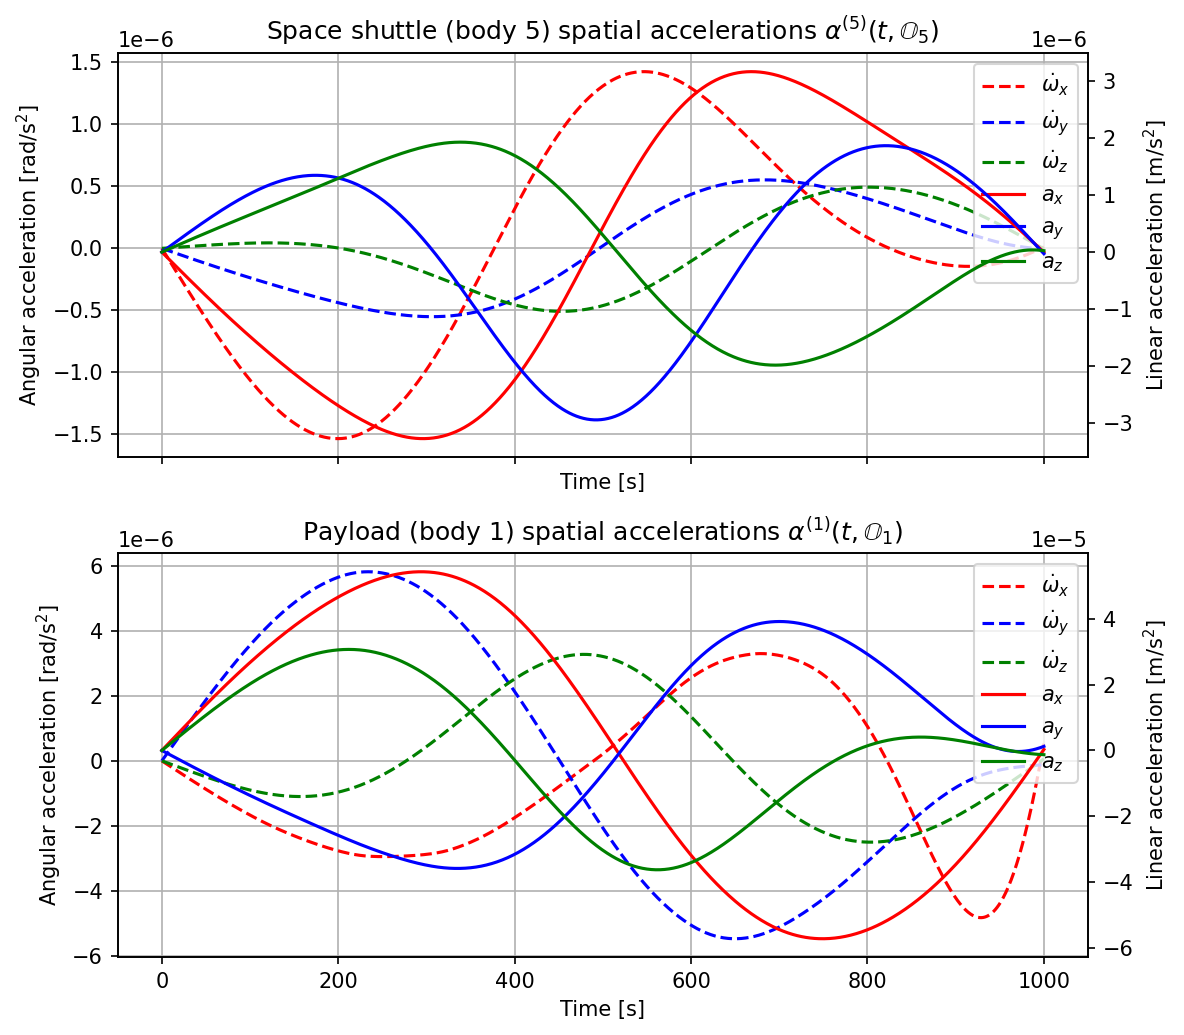

In [4]:
#Forces load
q2_forces_df = pd.read_csv("generalized_forces.csv")
time_numpy = q2_forces_df.pop("time").to_numpy()
forces_numpy = q2_forces_df.to_numpy()
forces_numpy = np.hstack((forces_numpy, np.zeros((forces_numpy.shape[0], 6))))

#Force interpolation spline
linear_interpolator = make_interp_spline(time_numpy, forces_numpy, k=1, axis=0)

#Define force function
def get_generalized_forces(time_indices, interpolator=linear_interpolator):
    generalized_forces = interpolator(time_indices)

    return generalized_forces

#Simulation settings
t_start = time_numpy[0]
t_end = time_numpy[-1]
t_eval = time_numpy#np.linspace(t_start, t_end, indices_numpy.shape[0])

#solve for timesteps
timeseries_solution = solve_ivp(
    state_space_differentiation, 
    (t_start, t_end), 
    initial_state, 
    t_eval=t_eval,
    args=(hinge_list, l_h, spatial_inertias, get_generalized_forces), 
    rtol=1e-4,
    atol=1e-4,)


#incrementing in time and calling scatter-gather loops:
t = timeseries_solution.t
spatial_alpha_history = np.empty(((len(hinge_list)+1)*6, len(timeseries_solution.t)))

for index, (time, state) in enumerate(zip(timeseries_solution.t, timeseries_solution.y.T)):
    theta = state[0:17].copy()
    beta = state[17:31].copy()

    generalized_forces = get_generalized_forces(time, linear_interpolator)

    spatial_velocities, a_tensor, phi_transposed_tensor, spatial_rotations = scatter_function(theta, beta, l_h, hinge_list)
    beta_dot, spatial_alpha = ATBI_function(spatial_velocities, spatial_inertias, a_tensor, phi_transposed_tensor, generalized_forces, hinge_list)


    spatial_alpha_history[:, index] = spatial_alpha

alpha_payload = spatial_alpha_history[1*6:2*6, :]   # body 1
alpha_shuttle = spatial_alpha_history[5*6:6*6, :]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 7), dpi=150, sharex=True)
plot_spatial_accel(ax_top, t, alpha_shuttle, "Space shuttle (body 5) spatial accelerations $\\alpha^{(5)}(t,\\mathbb{O}_5)$")
plot_spatial_accel(ax_bot, t, alpha_payload, "Payload (body 1) spatial accelerations $\\alpha^{(1)}(t,\\mathbb{O}_1)$")
plt.tight_layout()
plt.show()